In [1]:
import random
import numpy as np
from collections import defaultdict


In [2]:
class TrafficEnv:
    def __init__(self):
        self.lanes = [
            "N_left", "N_straight",
            "S_left", "S_straight",
            "E_left", "E_straight",
            "W_left", "W_straight"
        ]
        self.max_queue = 20
        self.phase = 0
        self.Q_lanes = {}
        self.W = {}

    def reset(self):
        self.Q_lanes = {lane: random.randint(0, 3) for lane in self.lanes}
        self.W = {lane: 0 for lane in self.lanes}
        self.phase = random.randint(0, 3)
        return self.get_state()

    def discretize(self, q):
        if q <= 4:   return 0
        elif q <= 9: return 1
        elif q <= 14: return 2
        else:         return 3  # added a 4th bin for saturated queues

    def get_state(self):
        state = [self.discretize(self.Q_lanes[lane]) for lane in self.lanes]
        state.append(self.phase)
        return tuple(state)

    def step(self, action):
        # Yellow phase penalty only on phase change
        if action != self.phase:
            for lane in self.lanes:
                self.W[lane] += 2  # yellow delay

        # Active lanes per action
        active_map = {
            0: ["N_straight", "S_straight"],
            1: ["N_left", "S_left"],
            2: ["E_straight", "W_straight"],
            3: ["E_left", "W_left"]
        }
        active = active_map[action]

        # Move cars — clear 3 per step (increased throughput)
        for lane in self.lanes:
            if lane in active:
                passed = min(3, self.Q_lanes[lane])
                self.Q_lanes[lane] -= passed
                self.W[lane] = max(0, self.W[lane] - passed)
            else:
                self.W[lane] += 1

        # Add new cars — reduced arrival rate so clearing is possible
        for lane in self.lanes:
            self.Q_lanes[lane] += random.randint(0, 1)  # was 0-2
            self.Q_lanes[lane] = min(self.Q_lanes[lane], self.max_queue)

        # Reward: penalize queue + waiting, normalized
        total_queue = sum(self.Q_lanes.values())
        total_wait = sum(self.W.values())
        reward = -(total_queue + 0.5 * total_wait) / (self.max_queue * len(self.lanes))

        self.phase = action
        return self.get_state(), reward



In [3]:
Q_table = defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])

alpha = 0.15          # higher for faster early learning
gamma = 0.95          # longer horizon
epsilon = 1.0         # start fully exploratory
epsilon_decay = 0.998 # slow decay over ~2300 episodes to reach min
epsilon_min = 0.05

def choose_action(state, eps):
    if random.random() < eps:
        return random.randint(0, 3)
    return int(np.argmax(Q_table[state]))


In [4]:
env = TrafficEnv()
episodes = 3000
steps_per_episode = 200
rewards = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    for t in range(steps_per_episode):
        action = choose_action(state, epsilon)
        next_state, reward = env.step(action)

        # Q-learning update
        Q_table[state][action] += alpha * (
            reward + gamma * max(Q_table[next_state]) - Q_table[state][action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)  # decay after each episode

    if ep % 50 == 0:
        window = min(50, len(rewards))
        avg = sum(rewards[-window:]) / window
        print(f"Episode {ep:4d} | Avg Reward: {avg:7.2f} | Epsilon: {epsilon:.3f}")

Episode    0 | Avg Reward: -934.72 | Epsilon: 0.998
Episode   50 | Avg Reward: -922.78 | Epsilon: 0.903
Episode  100 | Avg Reward: -916.60 | Epsilon: 0.817
Episode  150 | Avg Reward: -917.88 | Epsilon: 0.739
Episode  200 | Avg Reward: -893.02 | Epsilon: 0.669
Episode  250 | Avg Reward: -892.93 | Epsilon: 0.605
Episode  300 | Avg Reward: -888.00 | Epsilon: 0.547
Episode  350 | Avg Reward: -880.80 | Epsilon: 0.495
Episode  400 | Avg Reward: -871.43 | Epsilon: 0.448
Episode  450 | Avg Reward: -879.55 | Epsilon: 0.405
Episode  500 | Avg Reward: -861.36 | Epsilon: 0.367
Episode  550 | Avg Reward: -881.27 | Epsilon: 0.332
Episode  600 | Avg Reward: -872.33 | Epsilon: 0.300
Episode  650 | Avg Reward: -852.84 | Epsilon: 0.272
Episode  700 | Avg Reward: -827.16 | Epsilon: 0.246
Episode  750 | Avg Reward: -877.07 | Epsilon: 0.222
Episode  800 | Avg Reward: -843.63 | Epsilon: 0.201
Episode  850 | Avg Reward: -827.04 | Epsilon: 0.182
Episode  900 | Avg Reward: -860.41 | Epsilon: 0.165
Episode  950

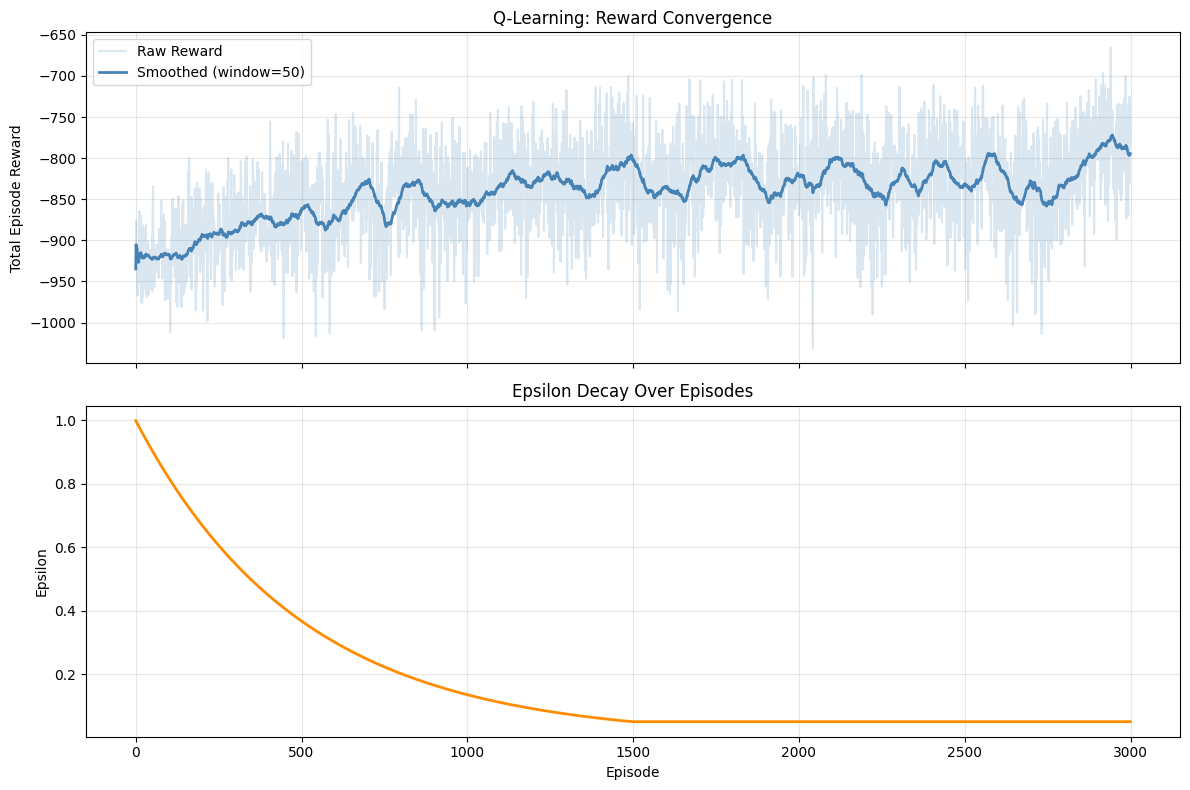

In [7]:
# ── Cell 1: Plot Rewards & Epsilon Decay ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def smooth(data, window=50):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

epsilons = []
eps = 1.0
for _ in range(3000):
    eps = max(0.05, eps * 0.998)
    epsilons.append(eps)

smoothed = smooth(rewards, window=50)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(rewards, alpha=0.2, color='steelblue', label='Raw Reward')
ax1.plot(smoothed, color='steelblue', linewidth=2, label='Smoothed (window=50)')
ax1.set_ylabel('Total Episode Reward')
ax1.set_title('Q-Learning: Reward Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epsilons, color='darkorange', linewidth=2)
ax2.set_ylabel('Epsilon')
ax2.set_xlabel('Episode')
ax2.set_title('Epsilon Decay Over Episodes')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ql_rewards_epsilon.png', dpi=150)
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import numpy as np

# --- Network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


# --- Replay Buffer ---
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states = zip(*batch)
        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states)
        )

    def __len__(self):
        return len(self.buffer)


# --- DQN Agent ---
class DQNAgent:
    def __init__(self, state_dim=9, action_dim=4):
        self.action_dim = action_dim
        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.buffer = ReplayBuffer(10000)
        self.batch_size = 64
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_decay = 0.998
        self.epsilon_min = 0.05
        self.update_target_every = 20
        self.steps = 0

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            q = self.policy_net(torch.FloatTensor(state))
        return int(q.argmax())

    def update(self):
        if len(self.buffer) < self.batch_size:
            return
        states, actions, rewards, next_states = self.buffer.sample(self.batch_size)

        q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
        target = rewards + self.gamma * max_next_q

        loss = nn.MSELoss()(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# --- Training ---
def state_to_tensor(state):
    return [float(s) / 4.0 for s in state]   # normalize: phase 0-3, bins 0-3

env_dqn = TrafficEnv()
agent = DQNAgent(state_dim=9, action_dim=4)

dqn_rewards = []
episodes = 3000
steps_per_episode = 200

for ep in range(episodes):
    state = env_dqn.reset()
    state_t = state_to_tensor(state)
    total_reward = 0

    for t in range(steps_per_episode):
        action = agent.choose_action(state_t)
        next_state, reward = env_dqn.step(action)
        next_state_t = state_to_tensor(next_state)

        agent.buffer.push(state_t, action, reward, next_state_t)
        agent.update()

        state_t = next_state_t
        total_reward += reward

    dqn_rewards.append(total_reward)
    agent.decay_epsilon()

    if ep % 50 == 0:
        window = min(50, len(dqn_rewards))
        avg = np.mean(dqn_rewards[-window:])
        print(f"Episode {ep:4d} | Avg Reward: {avg:7.2f} | Epsilon: {agent.epsilon:.3f}")

c:\Users\sayye\python_3.10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\sayye\python_3.10\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\sayye\python_3.10\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\sayye\AppData\Roaming\Python\Py

Episode    0 | Avg Reward: -847.41 | Epsilon: 0.998
Episode   50 | Avg Reward: -917.89 | Epsilon: 0.903
Episode  100 | Avg Reward: -930.28 | Epsilon: 0.817
Episode  150 | Avg Reward: -925.74 | Epsilon: 0.739
Episode  200 | Avg Reward: -911.83 | Epsilon: 0.669
Episode  250 | Avg Reward: -893.06 | Epsilon: 0.605
Episode  300 | Avg Reward: -909.68 | Epsilon: 0.547
Episode  350 | Avg Reward: -880.24 | Epsilon: 0.495
Episode  400 | Avg Reward: -884.42 | Epsilon: 0.448
Episode  450 | Avg Reward: -876.56 | Epsilon: 0.405
Episode  500 | Avg Reward: -823.84 | Epsilon: 0.367
Episode  550 | Avg Reward: -847.17 | Epsilon: 0.332
Episode  600 | Avg Reward: -840.94 | Epsilon: 0.300
Episode  650 | Avg Reward: -866.56 | Epsilon: 0.272
Episode  700 | Avg Reward: -866.61 | Epsilon: 0.246
Episode  750 | Avg Reward: -871.16 | Epsilon: 0.222
Episode  800 | Avg Reward: -864.87 | Epsilon: 0.201
Episode  850 | Avg Reward: -828.50 | Epsilon: 0.182
Episode  900 | Avg Reward: -867.39 | Epsilon: 0.165
Episode  950

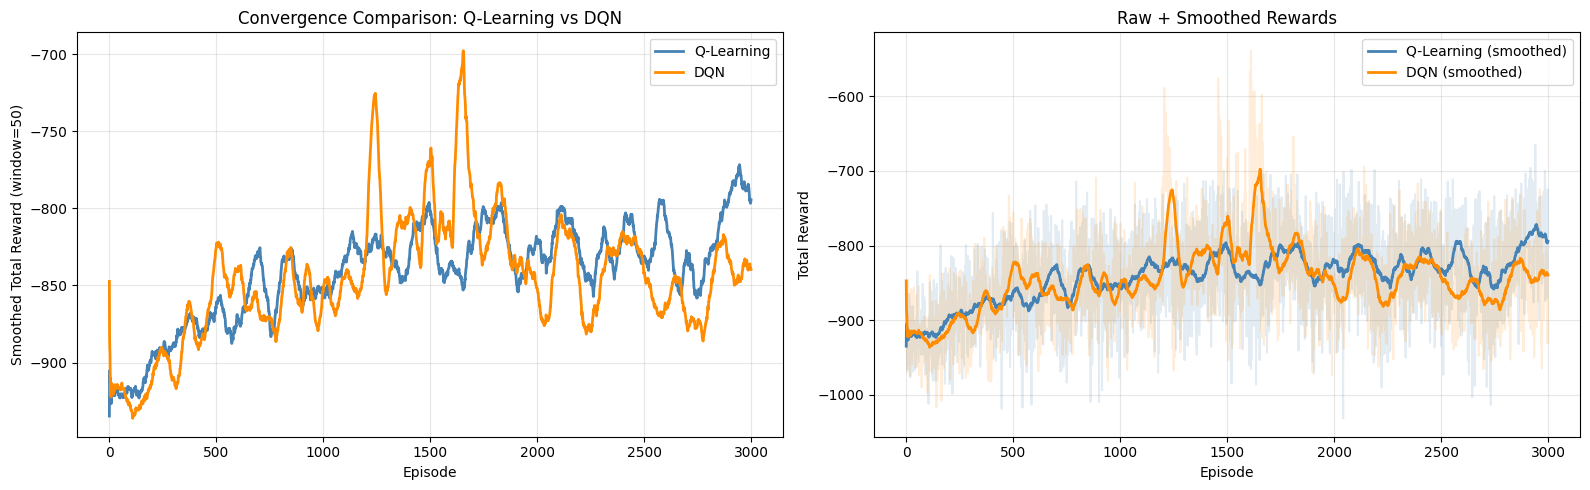


── Final 200-episode averages ──
Q-Learning :  -792.83  (std: 45.56)
DQN        :  -835.85  (std: 43.27)


In [9]:
# ── Cell 3: Convergence Comparison Plot ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def smooth(data, window=50):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

ql_smooth  = smooth(rewards,     window=50)
dqn_smooth = smooth(dqn_rewards, window=50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Smoothed reward comparison ---
ax = axes[0]
ax.plot(ql_smooth,  color='steelblue',  linewidth=2, label='Q-Learning')
ax.plot(dqn_smooth, color='darkorange', linewidth=2, label='DQN')
ax.set_xlabel('Episode')
ax.set_ylabel('Smoothed Total Reward (window=50)')
ax.set_title('Convergence Comparison: Q-Learning vs DQN')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Raw rewards (faint) + smoothed overlay ---
ax2 = axes[1]
ax2.plot(rewards,     alpha=0.15, color='steelblue')
ax2.plot(dqn_rewards, alpha=0.15, color='darkorange')
ax2.plot(ql_smooth,   color='steelblue',  linewidth=2, label='Q-Learning (smoothed)')
ax2.plot(dqn_smooth,  color='darkorange', linewidth=2, label='DQN (smoothed)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Total Reward')
ax2.set_title('Raw + Smoothed Rewards')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_comparison.png', dpi=150)
plt.show()

# --- Summary stats ---
last_n = 200
print(f"\n── Final {last_n}-episode averages ──")
print(f"Q-Learning : {np.mean(rewards[-last_n:]):8.2f}  (std: {np.std(rewards[-last_n:]):.2f})")
print(f"DQN        : {np.mean(dqn_rewards[-last_n:]):8.2f}  (std: {np.std(dqn_rewards[-last_n:]):.2f})")

In [10]:
# ── Cell: Save Models ─────────────────────────────────────────────────────────
import pickle
import torch
import json
import numpy as np
from collections import defaultdict

# Save Q-Learning table
q_table_serializable = {str(k): v for k, v in Q_table.items()}
with open("q_table.json", "w") as f:
    json.dump(q_table_serializable, f)
print("Q-table saved → q_table.json")

# Save DQN model weights
torch.save({
    'policy_net': agent.policy_net.state_dict(),
    'target_net': agent.target_net.state_dict(),
    'epsilon':    agent.epsilon,
}, "dqn_model.pth")
print("DQN model saved → dqn_model.pth")

# Save training rewards for frontend charts
with open("training_stats.json", "w") as f:
    json.dump({"ql_rewards": rewards, "dqn_rewards": dqn_rewards}, f)
print("Training stats saved → training_stats.json")

Q-table saved → q_table.json
DQN model saved → dqn_model.pth
Training stats saved → training_stats.json
